In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

In [2]:
# --- 1. CONFIGURATION ---
L = 3000.0  # Element size in meters

# --- 2. CALCULATE COORDINATES ---

# A. Physics Grid (pg2) - Evenly Spaced
# The element is divided into 2x2 sub-cells. 
# Centroids are at L/4 and 3L/4.
phys_1d = np.array([L/4.0, 3*L/4.0])

In [3]:
# Create 2D grid for Physics
phys_x, phys_y = np.meshgrid(phys_1d, phys_1d)

In [4]:
# B. Dynamics Grid (GLL Nodes) - Clustered
# Roots of derivative of Legendre polynomial (degree 3)
# Roots in [-1, 1]: -1, -sqrt(1/5), sqrt(1/5), 1
# Mapped to [0, L]
root_val = np.sqrt(1.0/5.0)
gll_1d_ref = np.array([-1.0, -root_val, root_val, 1.0])

In [5]:
# Map [-1, 1] -> [0, L]
gll_1d = (gll_1d_ref + 1.0) / 2.0 * L

In [6]:
# Create 2D grid for GLL
gll_x, gll_y = np.meshgrid(gll_1d, gll_1d)

In [ ]:
# Colors for the 4 Finite Volumes (Shaded Background)
colors = ['#FFEEEE', '#FFE0E0', '#FFE0E0', '#FFEEEE'] 

Text(750.0, 850.0, '(750, 750)')

Text(2250.0, 850.0, '(2250, 750)')

Text(750.0, 2350.0, '(750, 2250)')

Text(2250.0, 2350.0, '(2250, 2250)')

Text(0.0, -100, '0.0')

Text(829.1796067500632, -100, '829.2')

Text(2170.820393249937, -100, '2170.8')

Text(3000.0, -100, '3000.0')

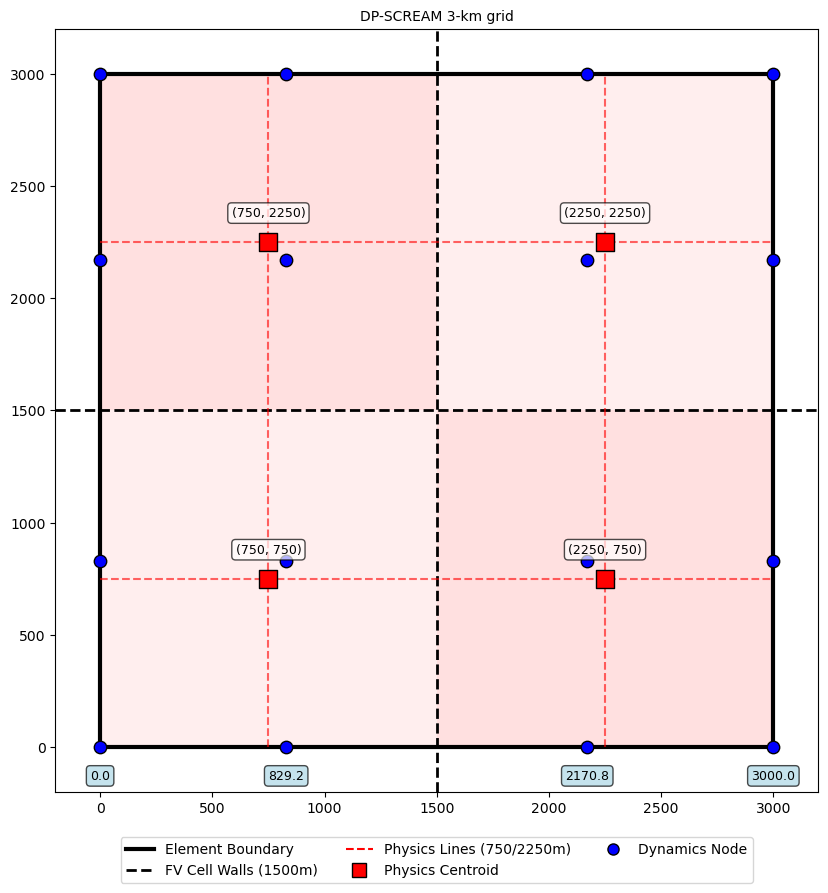

In [18]:
# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(9, 9))

# A. Draw the 4 Finite Volumes (Shaded Background)
idx = 0
for i in range(2):
    for j in range(2):
        x_corner = i * (L/2)
        y_corner = j * (L/2)
        rect = patches.Rectangle((x_corner, y_corner), L/2, L/2, 
                                    linewidth=0, facecolor=colors[idx], zorder=1)
        _= ax.add_patch(rect)
        idx = (idx + 1) % 4

# B. Draw Boundaries (Black Walls)
# Outer Element Boundary
outer_rect = patches.Rectangle((0, 0), L, L, 
                        linewidth=3, edgecolor='black', facecolor='none', 
                        label='Spectral Element Boundary', zorder=5)
_= ax.add_patch(outer_rect)

# Inner Cell Walls (The "Cross" at 1500m)
_ = ax.axvline(x=L/2, color='black', linestyle='--', linewidth=2, zorder=5)
_ = ax.axhline(y=L/2, color='black', linestyle='--', linewidth=2, zorder=5)

# --- UPDATED: Extend Red Lines to Edges ---
# We loop through the physics coordinates (750, 2250)
# and draw lines from 0 to L (3000)
for p in phys_1d:
    # Vertical Line (at x=750 and x=2250)
    _ = ax.plot([p, p], [0, L], color='red', linestyle='--', 
            linewidth=1.5, alpha=0.6, zorder=8)
    
    # Horizontal Line (at y=750 and y=2250)
    _ = ax.plot([0, L], [p, p], color='red', linestyle='--', 
            linewidth=1.5, alpha=0.6, zorder=8)

# C. Plot Nodes
# Physics Centroids
_ = ax.scatter(phys_x, phys_y, s=150, c='red', marker='s', 
            edgecolors='black', label='Physics Value', zorder=10)

# Annotate physics centroids with coordinates
for i in range(phys_x.shape[0]):
    for j in range(phys_x.shape[1]):
        x = phys_x[i, j]
        y = phys_y[i, j]
        ax.text(x, y + 100, f'({x:.0f}, {y:.0f})', 
                ha='center', va='bottom', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
                zorder=12)

# Dynamics/GLL Nodes
_ = ax.scatter(gll_x, gll_y, s=80, c='blue', marker='o', 
            edgecolors='black', label='Dynamics Node', zorder=11)

# Annotate GLL x-coordinates on y=0 line
for i, x in enumerate(gll_1d):
    ax.text(x, -100, f'{x:.1f}', 
            ha='center', va='top', fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7),
            zorder=12)

# --- 4. FORMATTING ---
_ = ax.set_xlim(-200, L + 200)
_ = ax.set_ylim(-200, L + 200)
_ = ax.set_aspect('equal')
_ = ax.set_title(f'DP-SCREAM 3-km grid', fontsize='medium')

# Legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='black', lw=3),
    Line2D([0], [0], color='black', lw=2, linestyle='--'),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, markeredgecolor='k')
]

_ = ax.legend(custom_lines, 
            ['Element Boundary', 'FV Cell Walls (1500m)', 'Physics Lines (750/2250m)', 'Physics Centroid', 'Dynamics Node'], 
            loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

plt.tight_layout()
plt.show()

